In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('07_RQ2_B_BTC_stacking_forward_validation.ipynb', source, ())

# 07 - RQ2_B: BTC stacking forward validation

## Methodology

The 12 H1-selected candidates comprise best single, all-nine soft vote, unanimity consensus and Logistic Regression stacking for each sentiment arm. DZ, confidence threshold, TP/SL and the 15-minute hold remain fixed. July 2025 base models use preceding 180-day histories; the meta-learner uses 2024 out-of-fold and completed H1 predictions.

July 2025 to March 2026 is a development-forward comparison with M1 TP/SL resolution and 5 bps per side. Sortino is primary; net return, Sharpe, trade counts and monthly stability are also reported. Forward adequacy requires 50 trades, 15 per side and six positive months. These results do not reselect the candidates. Q2-2026 is evaluated separately in Notebook 22.

In [2]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)

CODE_ROOT = Path.cwd().resolve()
if CODE_ROOT.name == 'notebooks':
    CODE_ROOT = CODE_ROOT.parent
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from experiments.all_model_stacking import DEFAULT_ROOT, MODEL_LABELS, VARIANTS

ROOT = DEFAULT_ROOT
manifest = json.loads((ROOT / 'manifest.json').read_text(encoding='utf-8'))
selected = pd.read_parquet(ROOT / 'h1_selected_candidates.parquet')
forward = pd.read_parquet(ROOT / 'forward_summary.parquet')
monthly = pd.read_parquet(ROOT / 'forward_monthly.parquet')
keys = ['sentiment_arm', 'variant']
for field in ['width_bps', 'policy_id', 'tau', 'tp_bps', 'sl_bps', 'max_hold']:
    assert selected.set_index(keys)[field].sort_index().equals(forward.set_index(keys)[field].sort_index())
assert len(forward) == 12 and len(monthly) == 108
assert pd.to_datetime(forward['period_end'], utc=True).max() == pd.Timestamp('2026-04-01', tz='UTC')
assert manifest['lockbox_2026_q2_used'] is False

## 1. Development-forward comparison

The table includes all H1-selected candidates, including sparse or economically inadequate rows. Net return is expressed as a fraction, so 0.01 denotes 1%.

In [3]:
from IPython.display import Markdown
forward_table = forward[[
    'Arm', 'variant', 'width_bps', 'selected_base_model', 'tau', 'tp_bps', 'sl_bps',
    'max_hold', 'trades', 'net_return', 'sortino', 'sharpe', 'positive_months', 'n_long', 'n_short'
]].copy()
forward_table['selected_base_model'] = forward_table['selected_base_model'].map(MODEL_LABELS).fillna('All nine')
forward_table['max_hold'] *= 15
forward_table['Pass forward guards'] = (
    (forward_table['trades'] >= 50) & (forward_table['n_long'] >= 15) &
    (forward_table['n_short'] >= 15) & (forward_table['positive_months'] >= 6)
)
forward_table.columns = [
    'Sentiment', 'Variant', 'DZ', 'Model set', 'Threshold', 'TP', 'SL', 'Hold (min)',
    'Trades', 'Net return', 'Sortino', 'Sharpe', 'Positive months', 'Long', 'Short', 'Pass forward guards'
]
forward_table = forward_table.sort_values(['Sortino', 'Sharpe', 'Net return'], ascending=False, ignore_index=True)
display(Markdown('All twelve H1-frozen candidates are replayed on July 2025–March 2026 with unchanged costs.'))
display(forward_table.round(3))

All twelve H1-frozen candidates are replayed on July 2025–March 2026 with unchanged costs.

,Sentiment,Variant,DZ,Model set,Threshold,TP,SL,Hold (min),Trades,Net return,Sortino,Sharpe,Positive months,Long,Short,Pass forward guards
0,No sentiment,best_single,55,LSTM,0.75,200,100,15,54,0.036,1.568,0.859,5,16,38,False
1,No sentiment,consensus,55,All nine,0.00,150,100,15,22,0.012,0.493,0.340,5,14,8,False
2,LLM,consensus,65,All nine,0.00,150,75,15,19,-0.049,-1.993,-1.552,3,18,1,False
3,DeBERTa,consensus,65,All nine,0.00,150,75,15,27,-0.061,-2.314,-1.811,2,22,5,False
4,No sentiment,stack,55,All nine,0.60,150,100,15,102,-0.108,-3.295,-2.593,3,58,44,False
5,DeBERTa,best_single,55,CatBoost,0.70,200,100,15,169,-0.261,-4.831,-4.026,3,141,28,False
6,LLM,soft_vote,65,All nine,0.55,200,100,15,354,-0.352,-5.186,-3.961,0,200,154,False
7,LLM,stack,65,All nine,0.65,150,100,15,477,-0.489,-6.596,-5.087,1,209,268,False
8,LLM,best_single,55,LSTM,0.70,200,100,15,593,-0.510,-6.693,-5.111,0,354,239,False
9,DeBERTa,soft_vote,55,All nine,0.55,150,75,15,370,-0.518,-7.624,-6.217,0,284,86,False


## 2. Stacking versus the single-model control

Each comparison pairs the stack with the H1-selected single-model control in the same sentiment arm.

In [4]:
from IPython.display import Markdown
comparison = []
for arm, group in forward.groupby('sentiment_arm', sort=False):
    single = group.loc[group['variant'] == 'best_single'].iloc[0]
    stack = group.loc[group['variant'] == 'stack'].iloc[0]
    comparison.append({
        'Sentiment': single['Arm'],
        'Single model': MODEL_LABELS[single['selected_base_model']],
        'Single DZ': int(single['width_bps']),
        'Single Sortino': single['sortino'],
        'Single Sharpe': single['sharpe'],
        'Single net': single['net_return'],
        'Stack DZ': int(stack['width_bps']),
        'Stack Sortino': stack['sortino'],
        'Stack Sharpe': stack['sharpe'],
        'Stack net': stack['net_return'],
        'Sortino delta': stack['sortino'] - single['sortino'],
        'Net delta': stack['net_return'] - single['net_return'],
    })
comparison = pd.DataFrame(comparison).sort_values('Stack Sortino', ascending=False, ignore_index=True)
display(Markdown('Stack-minus-single differences use the frozen comparator within each sentiment arm.'))
display(comparison.round(3))

Stack-minus-single differences use the frozen comparator within each sentiment arm.

,Sentiment,Single model,Single DZ,Single Sortino,Single Sharpe,Single net,Stack DZ,Stack Sortino,Stack Sharpe,Stack net,Sortino delta,Net delta
0,No sentiment,LSTM,55,1.568,0.859,0.036,55,-3.295,-2.593,-0.108,-4.863,-0.144
1,LLM,LSTM,55,-6.693,-5.111,-0.510,65,-6.596,-5.087,-0.489,0.097,0.021
2,DeBERTa,CatBoost,55,-4.831,-4.026,-0.261,55,-7.708,-6.204,-0.542,-2.877,-0.281


## 3. Monthly stability

The panels show how monthly net returns vary across the development-forward period.

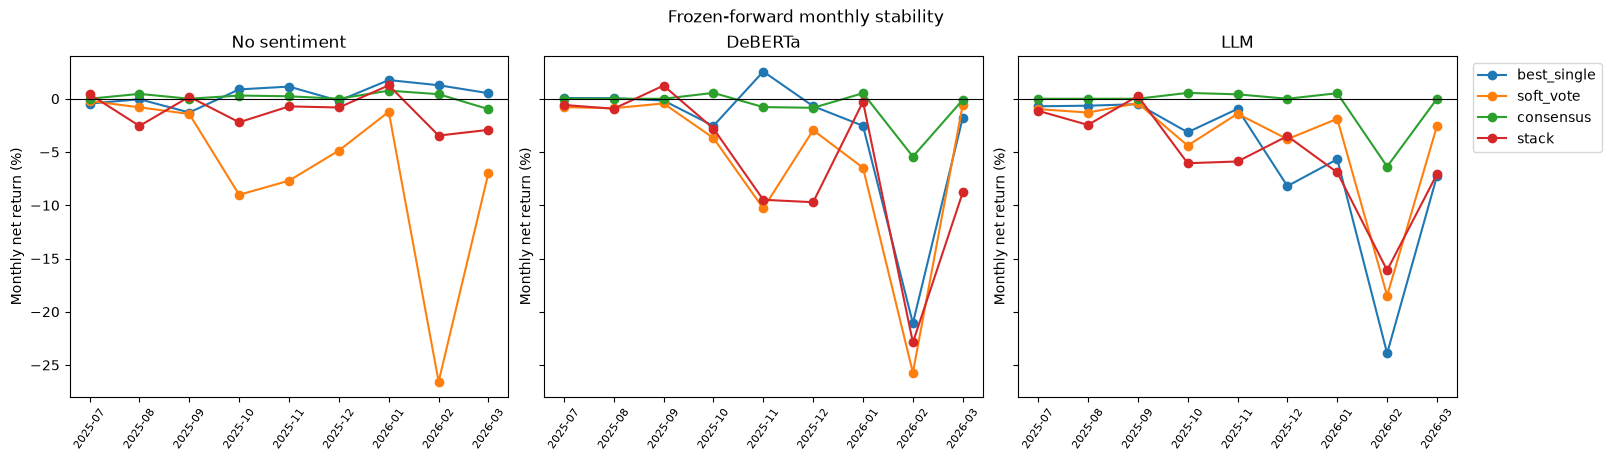

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True, constrained_layout=True)
for axis, (arm, group) in zip(axes, monthly.groupby('sentiment_arm', sort=False)):
    for variant in VARIANTS:
        series = group.loc[group['variant'] == variant].sort_values('period')
        axis.plot(series['period'], 100 * series['net_return'], marker='o', label=variant)
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set_title(group['Arm'].iloc[0])
    axis.tick_params(axis='x', rotation=55, labelsize=8)
    axis.set_ylabel('Monthly net return (%)')
axes[-1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
fig.suptitle('Frozen-forward monthly stability')
artifact_dir = CODE_ROOT / 'notebooks' / 'artifacts'
artifact_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(artifact_dir / '03a_stacking_monthly.png', dpi=180, bbox_inches='tight')
plt.show()

In [6]:
best = forward.sort_values(['sortino', 'sharpe', 'net_return'], ascending=False).iloc[0]
stack_wins = int((comparison['Sortino delta'] > 0).sum())
print(f"Best forward row: {best['Arm']} / {best['variant']} / DZ{int(best['width_bps'])}; "
      f"Sortino {best['sortino']:.3f}, Sharpe {best['sharpe']:.3f}, "
      f"net {best['net_return']:.2%}, trades {int(best['trades'])}.")
print(f'Stacking improves Sortino versus the frozen single control in {stack_wins}/3 sentiment arms.')

Best forward row: No sentiment / best_single / DZ55; Sortino 1.568, Sharpe 0.859, net 3.58%, trades 54.
Stacking improves Sortino versus the frozen single control in 1/3 sentiment arms.


## Results

The no-sentiment LSTM DZ55 single-model control has the highest forward Sortino (1.568) and net return (+3.58%) over 54 trades. All 12 candidates fail the forward adequacy rule; even this control has only five positive months. Stacking improves Sortino over its matched single model in one of three sentiment arms, and all three stacks lose after costs.

Takeaway: The development-forward comparison does not support replacing the single-model controls with all-nine stacking.